# VisionBlock

> Fill in a module description here


In [ ]:
#| default_exp data.vision.block

In [ ]:
#| hide
from nbdev.showdoc import *

In [ ]:
#| export
import numpy as np
import matplotlib.pyplot as plt
from fastcore.utils import *
import torch
from torchvision.transforms import v2


In [ ]:
#| export    
class RotateMaskTransform(torch.nn.Module):
    def __init__(self, rotation_k, mask, patch_size, cfg, data_config):
        super().__init__()
        self.k = rotation_k
        self.mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)
        self.patch_size = patch_size
        self.cfg = cfg
        self.data_config = data_config

    def forward(self, img):
        """
        Applies the following transformations to the input image:
        1. Rotate the image by 90 degrees k times.
        2. Apply a mask to the rotated image, if patch_size > 0.
        3. Normalize the image using the mean and std from the data configuration.

        Args:
            img (PIL Image): The input image to be transformed.
        Returns:
            torch.Tensor: The transformed image tensor.
        """

        img_tensor = v2.functional.to_image(img)
        img_tensor = v2.functional.to_dtype(img_tensor, dtype=torch.float32, scale=True)
        img_rot = torch.rot90(img_tensor, k=self.k, dims=[1,2]) 

        if self.patch_size > 0:
            img_masked = torch.max(img_rot, self.mask)
        else:
            img_masked = img_rot

        m_min, m_max = img_masked.min(), img_masked.max()
        if m_max > m_min:
            img_masked = (img_masked - m_min) / (m_max - m_min)

            
        img_normalized = v2.functional.normalize(
            img_masked, 
            mean=self.data_config[self.cfg.data.name].mean, 
            std=self.data_config[self.cfg.data.name].std
        )
        return img_normalized

## Vision Block

In [ ]:
#| export
class VisionBlock(torch.utils.data.Dataset):
    def __init__(self, cfg, idx, data_config, fds, train=True, transform=None):
        self.cfg = cfg
        self.data_config = data_config
        
        split = "train" if train else "test"
        if split == "test" and self.cfg.data.name == "tiny-imagenet":
            split = "valid"
            
        self.data = fds.load_partition(partition_id=idx, split=split)
        self.x_key = self.data_config[self.cfg.data.name].x
        self.y_key = self.data_config[self.cfg.data.name].y
        
        
        def build_transform(transform= None):
            if self.cfg.data.name == "mnist_rotated_batched_40":
                transform = RotateMaskTransform(
                    rotation_k=self.data.rotation_k, 
                    mask=self.data.silo_mask,
                    patch_size=2,
                    data_config=self.data_config,
                    cfg=self.cfg
                )
            
            elif not transform:
                transform = v2.Compose([
                    v2.ToImage(),            # 2. Convert to Tensor (H,W,C -> C,H,W)
                    v2.ToDtype(torch.float32, scale=True),
                    v2.Normalize(self.data_config[self.cfg.data.name].mean, 
                                self.data_config[self.cfg.data.name].std)
                ]) 
            elif transform:
                transform = transform

            else:
                raise ValueError("""Please provide a valid transform, or extend the `data_config` dictionary to handle the dataset.
                                    See `fedai.data.data` module.""")
            
            return transform

        def apply_transforms(batch):
            batch[self.x_key] = [self.transform(img) for img in batch[self.x_key]]
            return batch
        self.transform = build_transform(transform)
        self.partition_torch = self.data.with_transform(apply_transforms)
        
    def __getitem__(self, idx):        
        x = self.partition_torch[idx][self.x_key]
        y = self.partition_torch[idx][self.y_key]
        return {'image': x, 'label': y}

    def __len__(self):
        return len(self.data)

In [ ]:
#| hide
from fedai.data import IMG_DATA_CONFIGS
from flwr_datasets import FederatedDataset
from fedai.utils import *
from omegaconf import OmegaConf
from fedai.data.vision.partitioners import RotatedPatchedPartitioner

In [ ]:
#| hide
cfg = OmegaConf.load('./examples/cfg.yaml')
cfg.lr = 0.005
cfg.local_epochs = 5
cfg.tau = 0.1
cfg.batch_size = 32
cfg.data.name = "mnist_rotated_batched_40"
IMG_DATA_CONFIGS[cfg.data.name]

DatasetConfig(x='image', y='label', num_labels=10, mean=(0.1307,), std=(0.3081,), size=28)

In [ ]:
#| hide
partitioner = RotatedPatchedPartitioner(num_partitions=40, patch_size= 2)
test_partitioner = RotatedPatchedPartitioner(num_partitions=40, patch_size= 2)
fds = FederatedDataset(
    dataset="ylecun/mnist", 
    partitioners={"train": partitioner, "test": test_partitioner}
)

In [ ]:
#| hide
fds.load_partition(partition_id=0, split="train")

Partition 0: Cluster 1, Rot: 0°, Noise: 0.0%


Dataset({
    features: ['image', 'label'],
    num_rows: 1500
})

Partition 14: Cluster 2, Rot: 90°, Noise: 0.0%


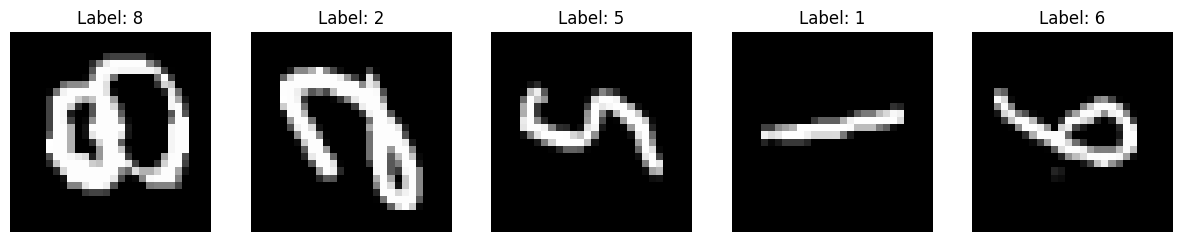

In [ ]:
#| hide
def plot_client_samples(partition, num_samples=5):
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))
    for i in range(num_samples):
        img = partition[i]['image'].squeeze()  # Remove channel dimension if present
        label = partition[i]['label']
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f"Label: {label}")
        axes[i].axis('off')
    plt.grid(True)
    plt.show()

idx = np.random.randint(0, fds.partitioners["train"].num_partitions)
client_data = VisionBlock(cfg, idx, IMG_DATA_CONFIGS, train= True, fds= fds)
plot_client_samples(client_data, num_samples=5)

Client 0 samples:
Partition 0: Cluster 1, Rot: 0°, Noise: 0.0%


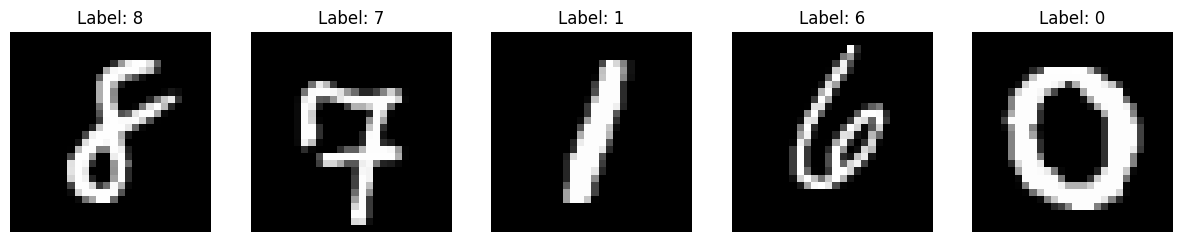

Client 11 samples:
Partition 11: Cluster 2, Rot: 90°, Noise: 0.0%


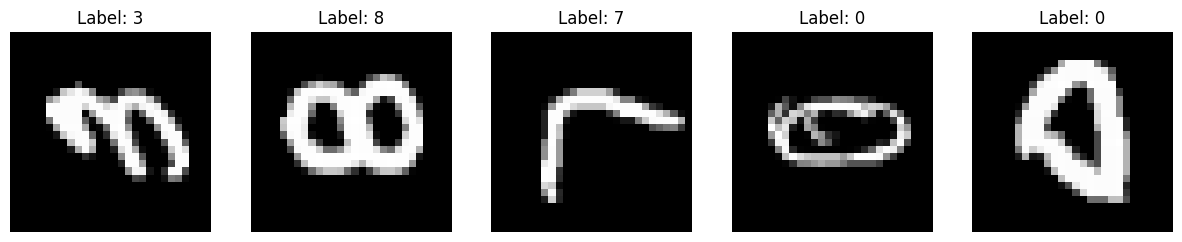

Client 22 samples:
Partition 22: Cluster 3, Rot: 180°, Noise: 15.0%


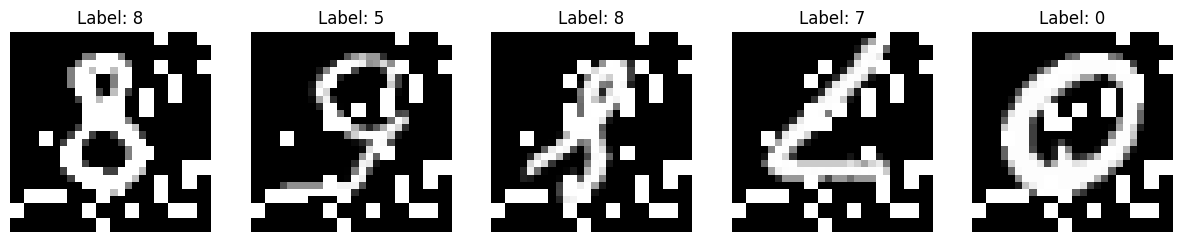

Client 33 samples:
Partition 33: Cluster 4, Rot: 270°, Noise: 50.0%


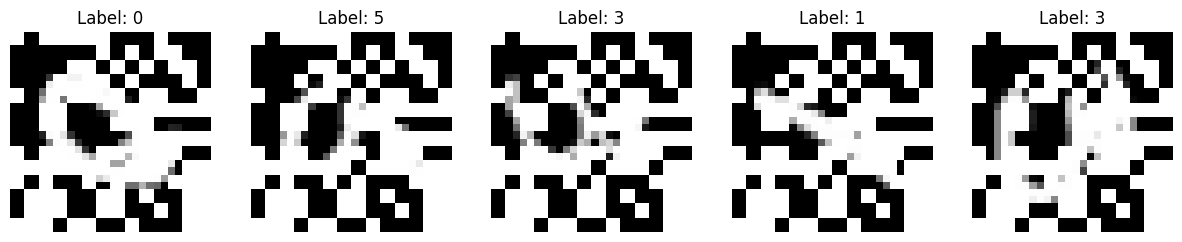

In [ ]:
#| hide
clients = [0, 11, 22, 33]
for idx in clients:
    print(f"Client {idx} samples:")
    client_data = VisionBlock(cfg, idx, IMG_DATA_CONFIGS, train= True, fds= fds)
    plot_client_samples(client_data, num_samples=5)
 

In [ ]:
#| hide
import nbdev
nbdev.nbdev_export()